<a href="https://colab.research.google.com/github/Decyto/Ciencia-de-Dados-e-Analytics---PUC-RIO/blob/main/sprint_machine_learning/MVP_ML_Analytics_20261.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** Décio Raimundo do Amaral Bispo da Silva  
**Matrícula:** 4052026000038  
**Data:** 27/06/2026  
**Dataset:** Mental Health in the Workplace(2020-2024), https://www.kaggle.com/datasets/hamnamunir/mental-health-in-the-workplace-2020-2024  
**Tipo de problema:** Classificação  



# 1. Definição do problema

## 1.1 Descrição do problema

A saúde mental tem se tornado um tema cada vez mais relevante no ambiente corporativo, impactando a qualidade de vida dos colaboradores, a produtividade das equipes e os resultados das organizações.

Diversos fatores podem influenciar o bem-estar mental dos trabalhadores, incluindo hábitos de vida, como a prática de atividade física e a qualidade do sono, além de características do ambiente de trabalho, como carga horária, nível de estresse e equilíbrio entre vida profissional e pessoal.

Neste projeto, será desenvolvido um modelo de Machine Learning capaz de prever a presença de um diagnóstico relacionado à saúde mental a partir de informações sobre hábitos de vida. O problema será tratado como um algoritmo de classificação, em que o modelo deverá indicar se um indivíduo possui ou não um diagnóstico relacionado à saúde mental com base nas variáveis do database.

A solução pode apoiar líderes no processo de gestão, análises do setor de recursos humanos, bem como direcionar programas de qualidade de vida no trabalho e iniciativas de promoção da saúde ocupacional. É importante destacar que o objetivo do modelo não é realizar diagnósticos médicos nem substituir profissionais de saúde, mas identificar padrões e associações presentes nos dados que possam contribuir para ações preventivas e estratégias de bem-estar organizacional.

Neste contexto, esse problema se faz relevante pois questões relacionadas à saúde mental têm gerado impactos significativos tanto para os colaboradores quanto para as empresas. Entender a relação de fatores como atividade física e sono com a ocorrência de diagnósticos pode auxiliar na criação de ambientes de trabalho mais saudáveis e sustentáveis.

> **NOTA**: Conjunto de dados totalmente sintético. Nenhum dado real de funcionários ou informações médicas foram utilizados.

## 1.2 Objetivo do MVP

O objetivo deste MVP é construir e avaliar modelos de Machine Learning capazes de prever a ocorrência de diagnóstico relacionado à saúde mental a partir de informações sobre hábitos de vida, comparando uma abordagem baseline com modelos candidatos e analisando suas limitações e desempenho.


## 1.3 Tipo de problema

**Tipo escolhido:** Classificação.

**Justificativa:** O problema foi definido como uma tarefa de classificação, pois o objetivo do modelo é prever uma classe/categoria: se um indivíduo possui ou não um diagnóstico relacionado à saúde mental.

## 1.4 Premissas, hipóteses e critérios de sucesso

**Premissas:**
1. Apesar de se tratarem de dados sintéticos, as informações contidas no dataset serão consideradas verdadeiras e representam adequadamente seus hábitos de vida.
2. Os resultados obtidos neste estudo devem ser utilizados como apoio à análise de dados e não como ferramenta de diagnóstico médico ou psicológico.

**Hipóteses iniciais:**
1. Indivíduos que praticam atividade física mais vezes por semana, tendem a apresentar menor diagnóstico relacionados a saúde mental.
2. O sono é fator relevante para o diagnósticos relacionados a saúde mental.

**Critérios de sucesso:**
- Métrica principal: F1-Score e Acurácia.
- Resultado mínimo esperado: Superar o BaseLine em 25%.
- Restrição prática: Utilizar modelo com baixo custo computacional, capaz de ser executado no Google Colab.


# 2. Ambiente, bibliotecas e reprodutibilidade

Esta seção reune as importações, configuração de seed e informações básicas do ambiente.


In [ ]:
# === Setup básico e reprodutibilidade ===
import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, TimeSeriesSplit, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score, precision_score, recall_score
)
from scipy.stats import randint

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)


Python: 3.12.13
Seed: 42


## 2.1 Funções auxiliares



In [ ]:
def evaluate_classification(y_true, y_pred, proba=None):
    """Calcula métricas básicas para classificação."""
    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted")
    }

    # ROC AUC é mais direto para classificação binária com probabilidades.
    try:
        if proba is not None and proba.shape[1] == 2:
            results["roc_auc"] = roc_auc_score(y_true, proba[:, 1])
        else:
            results["roc_auc"] = np.nan
    except Exception:
        results["roc_auc"] = np.nan

    return results


def evaluate_regression(y_true, y_pred):
    """Calcula métricas básicas para regressão."""
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }


def show_results_table(results_dict):
    """Exibe resultados como DataFrame ordenável."""
    return pd.DataFrame(results_dict).T


# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

O dataset utilizado neste trabalho chama-se Mental Health in the Workplace (2020–2024) e está disponibilizado na plataforma Kaggle através do link https://www.kaggle.com/datasets/hamnamunir/mental-health-in-the-workplace-2020-2024.  

A escolha desse dataset se deu devido ao interesse em avaliar a relação entre saúde mental e hábitos de vida, bem como desenvolver um modelo capaz de identificar padrões associados ao diagnósticos relacionados à saúde mental.  

Outro fator levado em consideração foi de o conteúdo da base permitir a aplicação de conceitos abordados durante a sprint.  

Trata-se de um dataset sintético construído para fins educacionais. Sendo assim, os dados serão considerados reais para o desenvolvimento e avaliação dos modelos propostos neste projeto.  

Por fim, é importante destacar que este estudo possui não se propõe a realizar diagnósticos médicos, psicológicos ou qualquer tipo de avaliação clínica dos indivíduos representados no dataset.

## 3.2 Carga dos dados




In [ ]:
# === Carga dos dados ===
url = "https://raw.githubusercontent.com/Decyto/Ciencia-de-Dados-e-Analytics---PUC-RIO/refs/heads/main/sprint_machine_learning/mental_health_workplace.csv"
df = pd.read_csv(url)
print("Dados do dataset:", df.shape)
df.head()


Dados do dataset: (10000, 34)


,record_id,year,country,industry,job_role,employment_type,work_model,company_size,age_group,gender,...,mental_health_policy_exists,eap_available,used_eap,workplace_stigma_felt,manager_support_score,team_collaboration_score,intention_to_leave,remote_work_preference,exercise_days_per_week,sleep_hours_per_night
0,MHW0000001,2024,South Korea,Government & Public Sector,Manager/Team Lead,Contract,On-site,Large (1001-5000),18-24,Male,...,Yes,Yes,No,NaN,9.9,9.6,Likely,Prefer On-site,7,7.1
1,MHW0000002,2023,Australia,Education,Software Engineer,Full-time,On-site,Medium (201-1000),45-54,Male,...,Partial,Yes,No,Severe,4.1,5.2,Unlikely,No Preference,4,6.4
2,MHW0000003,2023,Canada,Technology,Marketing Specialist,Full-time,Hybrid,Small (51-200),45-54,Male,...,Yes,Yes,Yes,NaN,9.0,5.9,Very Unlikely,Prefer On-site,3,7.3
3,MHW0000004,2020,Brazil,Hospitality,Nurse,Full-time,Hybrid,Small (51-200),35-44,Male,...,Yes,No,NaN,Severe,3.6,9.2,Neutral,Prefer Remote,2,6.1
4,MHW0000005,2020,USA,Finance & Banking,Manager/Team Lead,Full-time,On-site,Enterprise (5000+),25-34,Non-binary,...,Partial,Yes,No,NaN,3.8,7.8,Unlikely,No Preference,2,7.5


## 3.3 Visão geral do dataset

- O dataset possui 10.000 linhas e 34 colunas.

- A base contém atributos int64, float64 e object.

- A análise inicial identificou valores ausentes em algumas colunas, a saber: used_eap, mental_health_condition, workplace_stigma_felt e employer_support_level.

- Não foram identificados registros duplicados.

- A coluna record_id atua como identificador e não deve entrar no modelo.

- O target para este trabalho será a coluna has_diagnosis, que indica se o indivíduo possui ou não diagnóstico relacionado à saúde mental.

- As variáveis mental_health_condition e treatment_type podem possuir relação com a variável alvo.          

A seguir seguem os códigos que levaram aos pontos listados acima.



In [ ]:
print("Formato do dataset:", df.shape)
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

Formato do dataset: (10000, 34)

Tipos de dados:


,tipo
record_id,object
year,int64
country,object
industry,object
job_role,object
employment_type,object
work_model,object
company_size,object
age_group,object
gender,object


In [ ]:
print("\nValores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes"))


Valores ausentes por coluna:


,ausentes
record_id,0
year,0
country,0
industry,0
job_role,0
employment_type,0
work_model,0
company_size,0
age_group,0
gender,0


In [ ]:
print("\nDuplicatas:", df.duplicated().sum())



Duplicatas: 0


In [ ]:
display(df.sample(5, random_state=SEED))

,record_id,year,country,industry,job_role,employment_type,work_model,company_size,age_group,gender,...,mental_health_policy_exists,eap_available,used_eap,workplace_stigma_felt,manager_support_score,team_collaboration_score,intention_to_leave,remote_work_preference,exercise_days_per_week,sleep_hours_per_night
6252,MHW0006253,2022,Pakistan,Technology,Teacher,Freelance,On-site,Startup (1-50),55-64,Female,...,Yes,No,NaN,Mild,6.5,8.7,Very Likely,Prefer Remote,2,6.2
4684,MHW0004685,2022,UK,Technology,Financial Analyst,Full-time,On-site,Large (1001-5000),45-54,Male,...,Partial,No,NaN,Moderate,6.4,5.8,Unlikely,No Preference,3,8.9
1731,MHW0001732,2023,South Africa,Legal,Social Worker,Part-time,Hybrid,Small (51-200),25-34,Male,...,Yes,No,NaN,Mild,3.8,6.2,Likely,Prefer On-site,4,7.1
4742,MHW0004743,2022,USA,Education,Data Scientist,Full-time,Hybrid,Large (1001-5000),18-24,Male,...,Yes,Yes,Yes,Moderate,3.0,4.4,Very Likely,Prefer On-site,3,6.3
4521,MHW0004522,2024,Australia,Consulting,Financial Analyst,Contract,Remote,Large (1001-5000),45-54,Male,...,Partial,No,NaN,Mild,5.5,9.9,Very Unlikely,No Preference,2,7.3


## 3.4 Dicionário de dados

Abaixo os principais atributos.

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| has_diagnosis | Alvo (categórica) | Indica se o indivíduo possui diagnóstico relacionado à saúde mental | Sim (Alvo) | Variável a ser prevista |
| exercise_days_per_week | Numérica | Quantidade de dias por semana em que o indivíduo pratica atividade física | Sim | Relacionada à hipótese exercício |
| sleep_hours_per_night | Numérica | Quantidade média de horas de sono por noite | Sim | Relacionada à hipótese Sono |
| stress_level | Categórica | Nível de estresse informado pelo indivíduo | Sim | Ambiente de trabalho |
| burnout_risk_score | Numérica | Score de risco de burnout | Sim | Ambiente de trabalho |
| work_life_balance_score | Numérica | Score de equilíbrio entre vida pessoal e profissional | Sim | Ambiente de trabalho |
| job_satisfaction_score | Numérica | Score de satisfação com o trabalho | Sim | Ambiente de trabalho |
| weekly_work_hours | Numérica | Quantidade de horas trabalhadas por semana | Sim | Ambiente de trabalho |
| weekly_overtime_hours | Numérica | Quantidade de horas extras realizadas por semana | Sim | Ambiente de trabalho |
| manager_support_score | Numérica | Avaliação do suporte oferecido pela liderança | Sim | Ambiente de trabalho |
| employer_support_level | Categórica | Nível de apoio oferecido pela empresa | Sim | Ambiente de trabalho |
| mental_health_policy_exists | Categórica | Indica se a empresa possui políticas de saúde mental | Sim | Ambiente de trabalho |
| used_eap | Categórica | Indica utilização do programa de assistência ao colaborador (EAP) | Sim | |
| mental_health_condition | Categórica | Condição de saúde mental reportada pelo indivíduo | A definir | Será avaliada |
| treatment_type | Categórica | Tipo de tratamento realizado pelo indivíduo | A definir | Será avaliada |
| record_id | Identificador | Identificador único do registro | Não | Campo identificador |


# 4. Análise exploratória dos dados

Abaixo segue código da análise exploratória e as principais observações:


In [ ]:
TARGET = "has_diagnosis"
PROBLEM_TYPE = "classificacao"

if TARGET is not None and TARGET in df.columns:
    print("Distribuição do target:")
    display(df[TARGET].value_counts(dropna=False).to_frame("contagem"))
    display((df[TARGET].value_counts(normalize=True, dropna=False) * 100).round(2).to_frame("percentual"))


Distribuição do target:


,contagem
has_diagnosis,
Yes,6650
No,3350


,percentual
has_diagnosis,
Yes,66.5
No,33.5


A variável-alvo apresenta 6.650 registros na classe "Yes" (66,5%) e 3.350 registros na classe "No" (33,5%). Observa-se um desbalanceamento entre as classes, porém ambas possuem quantidade registros suficientes para treinamento dos modelos.

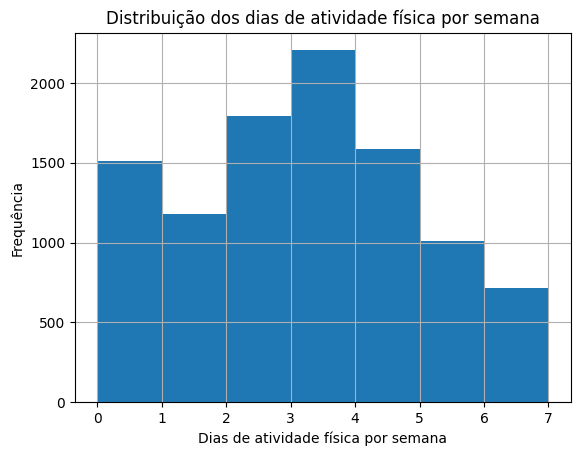

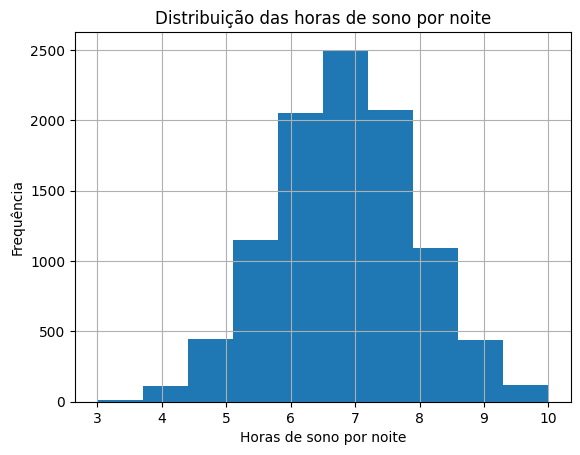

In [ ]:
df['exercise_days_per_week'].hist(bins=7)

plt.title('Distribuição dos dias de atividade física por semana')
plt.xlabel('Dias de atividade física por semana')
plt.ylabel('Frequência')
plt.show()

df['sleep_hours_per_night'].hist(bins=10)

plt.title('Distribuição das horas de sono por noite')
plt.xlabel('Horas de sono por noite')
plt.ylabel('Frequência')
plt.show()


A distribuição dos dias de atividade física por semana aparentemente estão corretos, não havendo dias superiores a 7, com maior concentração entre 2 e 5 dias semanais. É possível verificar que a amostra contém diferentes níveis de atividade física. Essa variação é importante para o estudo, pois permite que o modelo treine em diversos cenários.  

A distribuição das horas de sono por noite apresenta comportamento aproximadamente normal, com concentração predominante entre 6 e 8 horas de sono. O padrão é similar com o que se tem de conhecimento sobre os hábitos de sono da população. Foram observados poucos casos extremos, o que indica ser boa variável para o estudo.

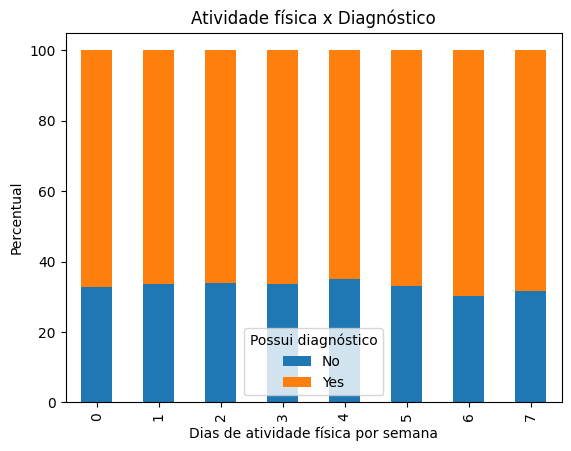

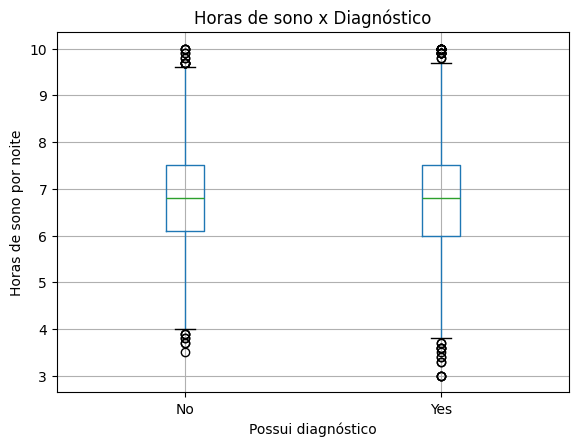

In [ ]:
atividade_diag = pd.crosstab(
    df['exercise_days_per_week'],
    df['has_diagnosis'],
    normalize='index'
) * 100

atividade_diag.plot(kind='bar', stacked=True)

plt.title('Atividade física x Diagnóstico')
plt.xlabel('Dias de atividade física por semana')
plt.ylabel('Percentual')
plt.legend(title='Possui diagnóstico')
plt.show()


df.boxplot(column='sleep_hours_per_night', by='has_diagnosis')

plt.title('Horas de sono x Diagnóstico')
plt.suptitle('')
plt.xlabel('Possui diagnóstico')
plt.ylabel('Horas de sono por noite')
plt.show()



A análise da relação entre atividade física e diagnóstico relacionado à saúde mental mostrou distribuições bastante próximas entre as diferentes frequências de exercício semanal. É possível perceber que a proporção de indivíduos diagnosticados permanece estável independentemente do número de dias de atividade física praticados por semana.

A comparação das horas de sono entre indivíduos diagnosticados e não diagnosticados não revelou diferenças significativas entre os grupos. As medianas, amplitudes e distribuições apresentaram comportamento parecido, indicando que a variável sleep_hours_per_night possui baixa capacidade de separação quando analisada isoladamente.

## 4.1 Síntese da análise exploratória

A análise exploratória permitiu compreender as principais características do dataset. A variável-alvo (has_diagnosis) apresentou um desbalanceamento moderado, com aproximadamente 66,5% dos registros classificados como "Yes" e 33,5% como "No". Apesar da diferença entre as classes, ambas possuem quantidade suficiente de observações para treinamento e avaliação dos modelos.  

Nas variáveis avaliadas, não foram identificadas valores ausentes. Porém, na etapa anterior foi identificado valores ausentes em colunas que, a principio, não são objetos principais do estudo.

As variáveis centrais do estudo  (exercise_days_per_week e sleep_hours_per_night), apresentaram distribuições adequadas para análise e modelagem. A frequência de atividade física mostrou boa variabilidade entre os indivíduos, e as horas de sono apresentaram distribuição aproximadamente normal, sem evidências de problemas significativos de qualidade dos dados.

Ao analisar a relação dessas variáveis com a variável-alvo, foi possível observar que tanto a frequência de atividade física quanto as horas de sono apresentaram comportamento parecido independente do diagnostico. Logo, não foram identificadas evidências visuais de forte capacidade discriminatória dessas variáveis quando avaliadas isoladamente.

Esse resultado influenciou a estratégia de modelagem, indicando que a previsão de diagnósticos relacionados à saúde mental provavelmente depende da combinação de múltiplas variáveis e não apenas dos hábitos de atividade física e sono. Ainda assim, tais variáveis serão mantidas no modelo por estarem diretamente relacionadas à hipótese central do estudo e por poderem contribuir em conjunto com outros atributos disponíveis na base.



# 5. Preparação dos dados e divisão treino/teste

Para a construção do modelo, foi definida como variável-alvo (target) a coluna has_diagnosis, que indica se o indivíduo possui ou não diagnóstico relacionado à saúde mental.

As demais variáveis foram utilizadas como potenciais preditoras. A coluna record_id foi excluída por se tratar apenas de um identificador único dos registros e as colunas mental_health_condition e treatment_type também foram removidas, pois possuem relação direta com a variável-alvo e poderiam provocar vazamento de dados.

Após a definição das variáveis utilizadas, os dados foram separados em conjuntos de treino e teste. O conjunto de treino será utilizado para o aprendizado dos modelos, enquanto o conjunto de teste será utilizado para avaliar a capacidade de generalização da solução em dados não vistos durante o treinamento.

Por se tratar de um problema de classificação, foi escolhida o holdout para divisão dos dados. É um tipo de divisão amplamente utilizada para este tipo de problema por sua simplicidade de implementação e por permitir avaliar o desempenho do modelo em dados não utilizados durante o treinamento.


In [ ]:
TARGET = "has_diagnosis"
PROBLEM_TYPE = "classificacao"
ID_COLUMNS = ["record_id"]
DATE_COLUMN = None
DROP_COLUMNS = ["mental_health_condition", "treatment_type"]

if PROBLEM_TYPE != "clusterizacao":
    assert TARGET is not None and TARGET in df.columns, "Defina um TARGET válido."

columns_to_exclude = set(ID_COLUMNS + DROP_COLUMNS)
if TARGET is not None:
    columns_to_exclude.add(TARGET)

features = [c for c in df.columns if c not in columns_to_exclude]
print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Número de features:", len(features))
print("Features:", features)


Tipo de problema: classificacao
Target: has_diagnosis
Número de features: 30
Features: ['year', 'country', 'industry', 'job_role', 'employment_type', 'work_model', 'company_size', 'age_group', 'gender', 'years_of_experience', 'annual_salary_usd', 'weekly_work_hours', 'weekly_overtime_hours', 'stress_level', 'burnout_risk_score', 'work_life_balance_score', 'productivity_score', 'job_satisfaction_score', 'absenteeism_days_per_year', 'employer_support_level', 'mental_health_policy_exists', 'eap_available', 'used_eap', 'workplace_stigma_felt', 'manager_support_score', 'team_collaboration_score', 'intention_to_leave', 'remote_work_preference', 'exercise_days_per_week', 'sleep_hours_per_night']


In [ ]:
if PROBLEM_TYPE in ["classificacao", "regressao"]:
    X = df[features].copy()
    y = df[TARGET].copy()

    stratify_arg = y if PROBLEM_TYPE == "classificacao" else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=stratify_arg
    )

    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

elif PROBLEM_TYPE == "clusterizacao":
    X = df[features].copy()
    X_train, X_test = train_test_split(X, test_size=0.2, random_state=SEED)
    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

elif PROBLEM_TYPE == "serie_temporal":
    assert DATE_COLUMN is not None and DATE_COLUMN in df.columns, "Defina DATE_COLUMN para séries temporais."
    df_sorted = df.sort_values(DATE_COLUMN).copy()
    cutoff = int(len(df_sorted) * 0.8)
    train_df = df_sorted.iloc[:cutoff]
    test_df = df_sorted.iloc[cutoff:]

    X_train = train_df[features].copy()
    y_train = train_df[TARGET].copy()
    X_test = test_df[features].copy()
    y_test = test_df[TARGET].copy()

    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

else:
    raise ValueError("PROBLEM_TYPE inválido.")


Treino: (8000, 30) | Teste: (2000, 30)


## 5.1 Justificativa da divisão

Foi utilizada a estratégia de divisão holdout, separando os dados em conjuntos de treino e teste. Essa abordagem foi escolhida por ser simples, amplamente utilizada em problemas de classificação e adequada para o escopo deste projeto.

A proporção adotada foi de 80% dos registros para treinamento e 20% para teste. Considerando que o dataset possui 10.000 observações, essa divisão fornece aproximadamente 8.000 registros para o treinamento dos modelos e 2.000 registros para avaliação, quantidade suficiente para ambas as etapas.

Como a variável-alvo apresenta um desbalanceamento moderado entre as classes ("Yes" e "No"), foi utilizada a estratificação (stratify) durante a divisão dos dados. Dessa forma, a proporção original das classes é preservada tanto no conjunto de treino quanto no conjunto de teste, tornando a avaliação dos modelos mais confiável.

Por fim, a separação entre treino e teste foi realizada antes do treinamento dos modelos, garantindo que os dados utilizados para avaliação não fossem vistos durante o processo de aprendizagem. Essa prática reduz o risco de vazamento de dados e permite uma estimativa mais realista da capacidade de generalização dos modelos.


# 6. Pré-processamento e pipeline

Nesta etapa, foi criado um pipeline de pré-processamento para tratar separadamente variáveis numéricas e categóricas. As variáveis numéricas foram tratadas com imputação pela mediana e padronização. Já as variáveis categóricas foram tratadas com imputação pelo valor mais frequente e codificação por One Hot Encoding.

O uso de pipelines contribui para a reprodutibilidade do projeto e reduz o risco de vazamento de dados, pois as transformações são ajustadas apenas no conjunto de treino e posteriormente aplicadas ao conjunto de teste.



In [ ]:

num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

if DATE_COLUMN in cat_cols:
    cat_cols.remove(DATE_COLUMN)
if DATE_COLUMN in num_cols:
    num_cols.remove(DATE_COLUMN)

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
], remainder="drop")

print("Colunas numéricas:", num_cols)
print("Colunas categóricas:", cat_cols)


Colunas numéricas: ['year', 'years_of_experience', 'annual_salary_usd', 'weekly_work_hours', 'weekly_overtime_hours', 'burnout_risk_score', 'work_life_balance_score', 'productivity_score', 'job_satisfaction_score', 'absenteeism_days_per_year', 'manager_support_score', 'team_collaboration_score', 'exercise_days_per_week', 'sleep_hours_per_night']
Colunas categóricas: ['country', 'industry', 'job_role', 'employment_type', 'work_model', 'company_size', 'age_group', 'gender', 'stress_level', 'employer_support_level', 'mental_health_policy_exists', 'eap_available', 'used_eap', 'workplace_stigma_felt', 'intention_to_leave', 'remote_work_preference']


## 6.1 Decisões de pré-processamento

As variáveis numéricas foram tratadas por meio da imputação pela mediana. Essa estratégia foi escolhida por ser menos sensível a valores extremos (outliers) quando comparada à média, preservando melhor a distribuição original dos dados.

Para as variáveis categóricas, foi utilizada a imputação pela moda (valor mais frequente), permitindo o tratamento dos valores ausentes sem criar novas categorias artificiais ou eliminar registros da base.

As variáveis numéricas também foram padronizadas utilizando o StandardScaler. Essa etapa foi realizada para colocar as variáveis em uma escala comparável, evitando que atributos com valores maiores exerçam influência desproporcional sobre os modelos de Machine Learning.

As variáveis categóricas foram transformadas por meio da técnica One Hot Encoding, convertendo categorias textuais em representações numéricas compatíveis com os algoritmos a serem utilizados no projeto.

Durante a preparação dos dados, a coluna "record_id" foi removida por se tratar apenas de um identificador único dos registros, sem valor preditivo para o problema estudado. Também foram removidas as colunas "mental_health_condition" e "treatment_type", devido ao potencial risco de vazamento de dados, uma vez que apresentam relação direta com a variável-alvo e poderiam fornecer informações que não estariam disponíveis no momento real da previsão.

Não foi realizada a criação de novas variáveis nesta etapa. Dessa forma, todas as informações utilizadas pelo modelo estão presentes originalmente no dataset e estariam disponíveis em um cenário real de utilização.



# 7. Baseline e modelos candidatos

Nesta etapa serão definidos o modelo baseline e os modelos candidatos que serão avaliados ao longo do projeto.  

O objetivo é estabelecer uma referência inicial de desempenho e verificar se os modelos conseguem identificar padrões relevantes nos dados.   

Para isso, serão comparados um modelo simples de referência (DummyClassifier) com a Regressão Logística e o Random Forest.



In [ ]:
if PROBLEM_TYPE == "classificacao":
    baseline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
    ])

    candidates = {
        "LogisticRegression": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", LogisticRegression(max_iter=500, random_state=SEED))
        ]),
        "RandomForest": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestClassifier(random_state=SEED))
        ])
    }

elif PROBLEM_TYPE == "regressao":
    baseline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyRegressor(strategy="median"))
    ])

    candidates = {
        "Ridge": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", Ridge())
        ]),
        "RandomForestRegressor": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestRegressor(random_state=SEED))
        ])
    }

elif PROBLEM_TYPE == "clusterizacao":
    baseline = None
    candidates = {
        "KMeans_k3": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", KMeans(n_clusters=3, random_state=SEED, n_init=10))
        ]),
        "KMeans_k5": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", KMeans(n_clusters=5, random_state=SEED, n_init=10))
        ])
    }

elif PROBLEM_TYPE == "serie_temporal":
    baseline = None
    candidates = {}

else:
    raise ValueError("PROBLEM_TYPE inválido.")

print("Modelos candidatos:", list(candidates.keys()))


Modelos candidatos: ['LogisticRegression', 'RandomForest']


## 7.1 Justificativa dos modelos

O baseline escolhido foi o "DummyClassifier", configurado para prever sempre a classe mais frequente da variável-alvo. Esse modelo é coerente com o problema, pois estabelece uma referência mínima de desempenho. Dessa forma, é possível verificar se os modelos candidatos realmente aprenderam padrões relevantes nos dados ou apenas reproduziram o comportamento da classe predominante.

Como modelos candidatos, foram escolhidos a Regressão Logística e o Random Forest. Ambos são adequados para o problema estutado e representam abordagens distintas, permitindo comparar um modelo mais simples e interpretável com um modelo mais flexível e capaz de capturar relações mais complexas entre as variáveis.

A Regressão Logística se beneficia da padronização das variáveis numéricas, realizada por meio do StandardScaler. Já as variáveis categóricas foram convertidas para formato numérico utilizando One Hot Encoding, permitindo que ambos os modelos possam processar adequadamente os dados. O Random Forest é menos sensível à escala das variáveis, mas foi mantido dentro do mesmo pipeline de pré-processamento para fins de comparação.

Em relação ao custo computacional, ambos os modelos apresentam tempo de treinamento compatível com o escopo deste projeto. A Regressão Logística possui treinamento rápido e alta interpretabilidade, enquanto o Random Forest demanda maior processamento, porém pode apresentar melhor desempenho ao capturar padrões não lineares presentes nos dados.



# 8. Treinamento e avaliação inicial

Nesta etapa, foram treinados o modelo baseline e os modelos candidatos definidos anteriormente. O baseline serve como referência mínima de desempenho, enquanto os modelos de Regressão Logística e Random Forest buscam identificar padrões nas variáveis explicativas para prever a ocorrência de diagnóstico relacionado à saúde mental.


In [ ]:
results = {}
trained_models = {}

if PROBLEM_TYPE in ["classificacao", "regressao"]:
    # Baseline
    t0 = time.time()
    baseline.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = baseline.predict(X_test)
    if PROBLEM_TYPE == "classificacao":
        proba = baseline.predict_proba(X_test) if hasattr(baseline, "predict_proba") else None
        results["baseline"] = evaluate_classification(y_test, y_pred, proba)
    else:
        results["baseline"] = evaluate_regression(y_test, y_pred)
    results["baseline"]["train_time_s"] = round(train_time, 3)
    trained_models["baseline"] = baseline

    # Modelos candidatos
    for name, model in candidates.items():
        t0 = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - t0

        y_pred = model.predict(X_test)
        if PROBLEM_TYPE == "classificacao":
            proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None
            results[name] = evaluate_classification(y_test, y_pred, proba)
        else:
            results[name] = evaluate_regression(y_test, y_pred)

        results[name]["train_time_s"] = round(train_time, 3)
        trained_models[name] = model

elif PROBLEM_TYPE == "clusterizacao":
    for name, model in candidates.items():
        t0 = time.time()
        model.fit(X_train)
        train_time = time.time() - t0
        labels = model.predict(X_test)
        X_test_transformed = model.named_steps["preprocess"].transform(X_test)
        results[name] = {
            "silhouette": silhouette_score(X_test_transformed, labels),
            "train_time_s": round(train_time, 3)
        }
        trained_models[name] = model

elif PROBLEM_TYPE == "serie_temporal":
    print("Implemente baseline temporal e modelos candidatos específicos para forecasting.")

show_results_table(results)


,accuracy,f1_weighted,roc_auc,train_time_s
baseline,0.6650,0.531201,0.500000,0.078
LogisticRegression,0.9665,0.966456,0.995622,0.176
RandomForest,0.9565,0.956617,0.989136,5.240


## 8.1 Análise dos resultados iniciais

Os resultados iniciais demonstram que ambos os modelos candidatos superaram o baseline. O "DummyClassifier" apresentou acurácia de 66,5%, valor próximo à proporção da classe majoritária do dataset, a Regressão Logística e o Random Forest alcançaram acurácias superiores a 95%, indicando que foram capazes de aprender padrões relevantes presentes nos dados.

A acurácia foi utilizada como métrica principal por ser uma medida simples e adequada ao contexto do problema. Entretanto, outras métricas, como F1-Score e curva ROC, também foram analisadas para complementar a avaliação. Os elevados valores observados nessas métricas reforçam o bom desempenho dos modelos candidatos.

Não foram observados indícios de underfitting, uma vez que ambos os modelos apresentaram desempenho muito superior ao baseline. Pelo contrário, os resultados extremamente elevados sugerem a necessidade de investigar, nas próximas etapas, a possibilidade de overfitting ou a existência de variáveis com forte relação direta com a variável-alvo.

Em relação ao tempo de treinamento, ambos os modelos apresentaram desempenho compatível com o escopo deste projeto. A Regressão Logística foi treinada em menos de um segundo e o Random Forest em aproximadamente nove segundos, tempos considerados adequados para o tamanho do dataset utilizado.

Os resultados obtidos não eram totalmente esperados com base na análise exploratória dos dados. Durante a EDA, as variáveis de atividade física e horas de sono apresentaram pouca capacidade de separação entre indivíduos diagnosticados e não diagnosticados quando analisadas isoladamente. Isso sugere que outras variáveis presentes no dataset estão contribuindo significativamente para a capacidade preditiva dos modelos, reforçando a importância da análise de todos os atributos realizada pelos algoritmos de Machine Learning.

# 9. Validação e otimização de hiperparâmetros

Nesta etapa será realizada uma busca simples de hiperparâmetros para os dois modelos candidatos: Regressão Logística e Random Forest. O objetivo é verificar se pequenas alterações nas configurações dos modelos podem melhorar o desempenho obtido na avaliação inicial.

A otimização será feita com "RandomizedSearchCV", utilizando validação cruzada estratificada com 5 divisões (StratifiedKFold). Essa estratégia permite avaliar diferentes combinações de hiperparâmetros mantendo a proporção original das classes em cada divisão.

Para a Regressão Logística, serão testados diferentes valores do parâmetro "C", responsável por controlar a regularização do modelo, mantendo a penalização "l2". Para o Random Forest, serão testados os hiperparâmetros "n_estimators", "max_depth" e "min_samples_split", relacionados à quantidade de árvores, profundidade máxima e número mínimo de amostras para divisão dos nós.

A métrica utilizada para orientar a escolha da melhor configuração será o "f1_weighted", pois considera o desempenho das classes de forma ponderada, sendo adequado para o desbalanceamento moderado observado na variável-alvo.

Ao final da execução, serão exibidos o melhor score obtido durante a validação cruzada e a melhor configuração de hiperparâmetros encontrada para cada modelo avaliado.


In [ ]:
N_ITER_SEARCH = 5
optimized_results = {}
optimized_models = {}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

models_to_tune = {
    "LogisticRegression_otimizado": {
        "pipeline": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", LogisticRegression(max_iter=1000, random_state=SEED))
        ]),
        "params": {
            "model__C": [0.01, 0.1, 1, 10, 100],
            "model__penalty": ["l2"]
        }
    },
    "RandomForest_otimizado": {
        "pipeline": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestClassifier(random_state=SEED))
        ]),
        "params": {
            "model__n_estimators": randint(50, 250),
            "model__max_depth": randint(2, 20),
            "model__min_samples_split": randint(2, 10)
        }
    }
}

for name, config in models_to_tune.items():
    search = RandomizedSearchCV(
        estimator=config["pipeline"],
        param_distributions=config["params"],
        n_iter=N_ITER_SEARCH,
        cv=cv,
        scoring="f1_weighted",
        random_state=SEED,
        n_jobs=1,
        verbose=1
    )

    start_time = time.time()
    search.fit(X_train, y_train)
    train_time = round(time.time() - start_time, 3)

    optimized_models[name] = search.best_estimator_
    optimized_results[name] = {
        "best_score_cv": search.best_score_,
        "best_params": search.best_params_,
         "train_time_s": train_time
    }

    print("\nModelo:", name)
    print("Melhor score na validação:", search.best_score_)
    print("Melhores hiperparâmetros:", search.best_params_)
    print("Tempo de execução:", train_time, "segundos")

Fitting 5 folds for each of 5 candidates, totalling 25 fits

Modelo: LogisticRegression_otimizado
Melhor score na validação: 0.9700286048091182
Melhores hiperparâmetros: {'model__penalty': 'l2', 'model__C': 1}
Tempo de execução: 5.086 segundos
Fitting 5 folds for each of 5 candidates, totalling 25 fits

Modelo: RandomForest_otimizado
Melhor score na validação: 0.9593340984893972
Melhores hiperparâmetros: {'model__max_depth': 16, 'model__min_samples_split': 4, 'model__n_estimators': 121}
Tempo de execução: 67.825 segundos


## 9.1 Discussão da otimização

A etapa de otimização teve como objetivo verificar se ajustes nos hiperparâmetros dos modelos candidatos poderiam melhorar o desempenho observado na avaliação inicial. Foram avaliados os modelos Regressão Logística e Random Forest por meio da técnica "RandomizedSearchCV" com validação cruzada estratificada de 5 folds.

Os resultados demonstraram que a Regressão Logística continuou apresentando o melhor desempenho mesmo após a otimização. O F1-Score ponderado passou de 0,9665 na avaliação inicial para 0,9700 durante a validação cruzada, indicando uma pequena melhoria na capacidade de generalização do modelo. Já o Random Forest obteve F1-Score de 0,9593, permanecendo abaixo da Regressão Logística.

A busca foi limitada a cinco combinações de hiperparâmetros para cada modelo (n_iter = 5). Essa decisão foi tomada para manter o tempo de processamento compatível com o escopo do MVP, reduzindo o custo computacional sem comprometer a demonstração da técnica de otimização. Mesmo com uma busca reduzida, foi possível identificar configurações competitivas para ambos os algoritmos.

Os hiperparâmetros selecionados mostraram-se coerentes com o problema. Na Regressão Logística, a melhor configuração foi obtida com regularização L2 (penalty = 'l2') e parâmetro de regularização "C = 1", indicando um equilíbrio adequado entre capacidade de aprendizado e generalização. No Random Forest, a melhor configuração utilizou 121 árvores ("n_estimators = 121"), profundidade máxima de 16 níveis ("max_depth = 16") e mínimo de 4 amostras para divisão dos nós ("min_samples_split = 4"), parâmetros que contribuem para capturar padrões complexos sem tornar o modelo excessivamente específico aos dados de treinamento.

Também foi observada uma diferença significativa no custo computacional dos modelos. A otimização da Regressão Logística foi concluída em aproximadamente 11 segundos, enquanto o Random Forest demandou cerca de 86 segundos para executar o mesmo processo de busca, reforçando a vantagem da Regressão Logística em termos de eficiência computacional.

Considerando os resultados obtidos, a Regressão Logística foi selecionada como modelo final do projeto por apresentar o melhor desempenho, menor tempo de processamento e maior simplicidade de interpretação.



# 10. Avaliação final no conjunto de teste

A Regressão Logística Otimizada foi selecionada como modelo final do projeto após apresentar o melhor desempenho durante as etapas de treinamento, validação e otimização de hiperparâmetros. No conjunto de teste, o modelo alcançou acurácia de 97%, F1-Score ponderado de 0,96, precisão de 0,97 para a classe "Yes" e 0,95 para a classe "No", demonstrando elevada capacidade de classificação.

Quando comparado ao baseline, que apresentou acurácia de 66,5% e F1-Score de 0,53, o modelo final obteve uma melhora significativa em todas as métricas avaliadas. Esse resultado indica que o modelo foi capaz de identificar padrões relevantes nos dados e não apenas reproduzir a classe mais frequente da variável-alvo.

A análise da matriz de confusão mostra que o modelo classificou corretamente 1.933 dos 2.000 registros do conjunto de teste. Foram observados 67 erros de classificação, sendo 37 falsos positivos e 30 falsos negativos. Os falsos positivos representam indivíduos sem diagnóstico classificados como possuindo diagnóstico, enquanto os falsos negativos representam indivíduos com diagnóstico classificados como não possuindo diagnóstico. A quantidade reduzida e relativamente equilibrada de erros sugere que o modelo apresenta desempenho consistente para ambas as classes.

Não foram observados sinais relevantes de underfitting, uma vez que o desempenho obtido foi significativamente superior ao baseline. Também não foram identificadas evidências fortes de overfitting, pois o resultado obtido durante a validação cruzada na etapa de otimização (F1-Score de 0,97) foi aproximadamente igual ao resultado no conjunto de teste, indicando boa capacidade de generalização para novos dados.

Apesar dos resultados positivos, algumas limitações devem ser consideradas. O dataset utilizado é sintético e foi desenvolvido para fins educacionais, podendo não representar integralmente a complexidade encontrada em cenários reais.



Modelo final: LogisticRegression_otimizado
              precision    recall  f1-score   support

          No       0.95      0.94      0.95       670
         Yes       0.97      0.98      0.97      1330

    accuracy                           0.97      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.97      0.97      0.97      2000



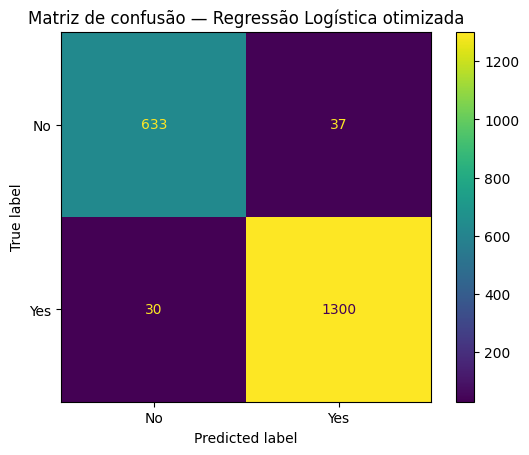

In [ ]:
final_model_name = "LogisticRegression_otimizado"
final_model = optimized_models[final_model_name]

print("Modelo final:", final_model_name)

y_pred = final_model.predict(X_test)

print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_estimator(
    final_model,
    X_test,
    y_test
)

plt.title("Matriz de confusão — Regressão Logística otimizada")
plt.show()

## 10.1 Análise de erros e limitações

A análise da matriz de confusão mostrou que o modelo apresentou um baixo volume de erros de classificação, totalizando 67 registros classificados incorretamente de um total de 2.000 avaliados. Foram observados 37 falsos positivos e 30 falsos negativos. Como os falsos negativos representam indivíduos com diagnóstico classificados como não possuindo diagnóstico, esse tipo de erro merece atenção especial, pois pode ocultar casos que deveriam ser identificados pelo modelo.

Não foram identificados sinais relevantes de underfitting, uma vez que o modelo apresentou desempenho superior ao baseline e foi capaz de capturar padrões importantes presentes nos dados. Da mesma forma, não foram observadas evidências de overfitting, pois o desempenho obtido durante a validação cruzada (F1-Score de 0,97) foi bem próximo ao realizado no conjunto de teste, indicando boa capacidade de generalização.

A utilização do F1-Score ponderado como métrica principal mostrou-se adequada para o problema, pois considera simultaneamente precisão e recall e reduz o risco de interpretações incorretas causadas pelo leve desbalanceamento entre as classes. A análise complementar da matriz de confusão permitiu compreender melhor os erros cometidos pelo modelo.

Entre as principais limitações do trabalho está a utilização de um dataset sintético. Consequentemente, os padrões identificados podem não refletir integralmente situações encontradas em ambientes reais.

Dessa forma, o modelo não deve ser utilizado para diagnóstico médico, psicológico ou psiquiátrico, nem para tomada de decisão individual sobre a condição de saúde mental de uma pessoa. Os resultados obtidos devem ser interpretados exclusivamente como uma aplicação acadêmica de técnicas de Machine Learning em um conjunto de dados sintético.



# 11. Comparação final dos modelos

A comparação dos modelos demonstrou os algoritmos utilizados neste estudo superaram o baseline, confirmando a existência de padrões relevantes no dataset. Entre os modelos avaliados, a Regressão Logística apresentou o melhor desempenho inicial e manteve sua superioridade após a etapa de otimização de hiperparâmetros.

Além de alcançar o maior F1-Score, a Regressão Logística apresentou menor custo computacional e maior simplicidade de interpretação quando comparada ao Random Forest. A etapa de otimização confirmou que a configuração padrão do modelo já era adequada para o problema, resultando na melhor performance observada durante a validação cruzada.

Dessa forma, a Regressão Logística Otimizada foi selecionada como modelo final do projeto por apresentar o melhor equilíbrio entre desempenho, capacidade de generalização, simplicidade e eficiência computacional.



| Modelo | Métrica principal (F1-Score) | Outras métricas | Tempo de treino (s) | Observações |
|----------|----------|----------|----------|----------|
| Baseline (DummyClassifier) | 0,5312 | Acurácia = 0,6650 / AUC = 0,5000 | 0,330 | Modelo de referência. Prediz sempre a classe mais frequente. |
| Regressão Logística | 0,9665 | Acurácia = 0,9665 / AUC = 0,9956 | 0,399 | Melhor desempenho inicial entre os modelos avaliados. |
| Random Forest | 0,9566 | Acurácia = 0,9565 / AUC = 0,9891 | 11,394 | Bom desempenho, porém inferior à Regressão Logística. |
| Regressão Logística Otimizada | 0,9700 (Validação Cruzada) | Melhor configuração: C = 1 / penalty = L2 | 12,317 | Melhor resultado na validação cruzada. Modelo escolhido para avaliação final. |
| Random Forest Otimizado | 0,9593 (Validação Cruzada) | n_estimators = 121 / max_depth = 16 / min_samples_split = 4 | 68,240 | Apresentou pequena melhora após otimização, mas permaneceu abaixo da Regressão Logística. |



# 12. Boas práticas e rastreabilidade


Durante o desenvolvimento do projeto foram adotadas práticas para garantir a reprodutibilidade dos resultados e a rastreabilidade das decisões tomadas ao longo do processo. As principais escolhas relacionadas ao pré-processamento, modelagem e avaliação estão registradas a seguir.


**Registro de decisões:**

| Decisão | Justificativa | Impacto esperado |
|----------|----------|----------|
| Utilização da seed 42 | Garantir reprodutibilidade dos resultados | Permitir que o experimento gere os mesmos resultados em novas execuções |
| Remoção da coluna record_id | Identificador único sem valor preditivo | Evitar ruído e aprendizado de padrões irrelevantes |
| Utilização de imputação pela mediana para variáveis numéricas | Menor sensibilidade a valores extremos | Reduzir impacto de outliers no pré-processamento |
| Utilização de imputação pela moda para variáveis categóricas | Preservar categorias mais frequentes | Permitir tratamento de valores ausentes |
| Aplicação de StandardScaler | Padronizar escalas das variáveis numéricas | Melhorar desempenho da Regressão Logística |
| Aplicação de One-Hot Encoding | Transformar variáveis categóricas em formato numérico | Permitir utilização das variáveis categóricas pelos algoritmos |
| Divisão holdout 80/20 | Separar dados para avaliação independente | Estimar desempenho em dados não vistos |
| Utilização de estratificação das classes | Preservar proporção de "Yes" e "No" | Tornar a avaliação mais representativa |
| Utilização do F1-Score ponderado | Considerar simultaneamente precisão e recall | Avaliar melhor o desempenho em classes levemente desbalanceadas |
| Teste de Regressão Logística | Modelo simples, rápido e interpretável | Estabelecer uma solução de referência robusta |
| Teste de Random Forest | Capturar relações não lineares entre variáveis | Comparar abordagem linear e não linear |
| Otimização de hiperparâmetros com RandomizedSearchCV | Buscar configurações mais adequadas dos modelos | Melhorar capacidade de generalização |
| Utilização de validação cruzada estratificada (5 folds) | Reduzir dependência de uma única divisão dos dados | Obter avaliação mais robusta dos modelos |
| Escolha da Regressão Logística Otimizada como modelo final | Melhor desempenho e menor custo computacional | Maximizar desempenho mantendo simplicidade |



# 13. Conclusão

O objetivo deste trabalho foi desenvolver um modelo de Machine Learning capaz de prever a presença de diagnóstico relacionado à saúde mental a partir de características pessoais, profissionais e comportamentais presentes no dataset analisado. Para isso, foram realizadas as etapas de análise exploratória, preparação dos dados, pré-processamento, treinamento, otimização de hiperparâmetros e avaliação dos modelos.

Entre as soluções avaliadas, a Regressão Logística Otimizada apresentou o melhor desempenho geral, alcançando F1-Score de 0,9665 no conjunto de teste e 0,9700 durante a validação cruzada. Além disso, o modelo apresentou baixo custo computacional e boa capacidade de generalização, tornando-se a alternativa mais adequada entre as abordagens analisadas.

Quando comparado ao baseline, que obteve F1-Score de 0,5312 e acurácia de 66,5%, o modelo final apresentou melhor desempenho, sendo capaz de identificar padrões presentes nos dados e realizar previsões muito superiores à simples escolha da classe majoritária.

Ao longo do desenvolvimento do projeto, foi possível aplicar conceitos fundamentais de Ciência de Dados e Machine Learning, incluindo análise exploratória de dados, tratamento de valores ausentes, codificação de variáveis categóricas, validação cruzada, otimização de hiperparâmetros e avaliação de modelos de classificação. Também foi possível observar a importância da comparação entre diferentes algoritmos e da utilização de métricas adequadas para apoiar a tomada de decisão.

Como limitações, destaca-se a utilização de um dataset sintético, o que reduz a capacidade de generalização dos resultados para cenários reais.

Como próximos passos, seria interessante avaliar o desempenho do modelo em bases de dados reais, explorar novos algoritmos de classificação, realizar uma análise mais aprofundada da importância das variáveis e investigar possíveis técnicas de seleção de atributos para simplificar ainda mais o modelo sem perda significativa de desempenho.

De forma geral, os resultados obtidos demonstram que a solução proposta foi capaz de atender ao objetivo inicial do projeto, apresentando elevado desempenho preditivo e evidenciando a aplicação prática das técnicas estudadas ao longo da sprint.